In [37]:
import math 
class Value:
    def __init__(self,data, _children=() , _op='' , label=''):
        self.data=data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out=Value(self.data + other.data , (self,other), '+')

    #chain rule inside add 
        def _backward():
          self.grad = 1.0 * out.grad
          other.grad = 1.0 * out.grad
        out._backward = _backward
        return out

    
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out=Value(self.data * other.data ,(self,other), '*')
        
#chain rule inside multiplication
        def _backward():
          self.grad = other.data * out.grad
          other.grad = self.data * out.grad
        out._backward = _backward
      
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
          self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
#https://www.mathsisfun.com/calculus/derivatives-rules.html
#check power rule 
       
    def __rmul__(self, other): # other * self
        return self * other
        
    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)
       
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
#chain rule inside the tanh function 
        def _backward():
           self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
    
        def _backward():
           self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
        out._backward = _backward
    
        return out
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
           if v not in visited:
             visited.add(v)
             for child in v._prev:
               build_topo(child)
               topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
               node._backward()





In [29]:
a = Value(2.0)
b = Value(4.0)
#a*3
#a._mul_(2)

#define rmul for below issue
#3 * a
#calling exp 
#a.exp()
#divide 

#a/b
#a *(1/b)
#a * ( b**=-1) #b to the power of -1 (1/b)
#x**k

a-b


Value(data=-2.0)

In [78]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        label_str = getattr(n, 'label', 'no label')
        data_val = getattr(n, 'data', 0.0)
        grad_val = getattr(n, 'grad', 0.0)
        op_str = getattr(n, '_op', '')
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (label_str, data_val, grad_val), shape='record')
        #dot.node(name=uid, label="{ %s | data %.4f  }" % (label_str, data_val), shape='record')
        if op_str:
            dot.node(name=uid + op_str, label=op_str)
            dot.edge(uid + op_str, uid)
    for n1, n2 in edges:
        op_str = getattr(n2, '_op', '')
        dot.edge(str(id(n1)), str(id(n2)) + op_str)
    return dot
    


In [30]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

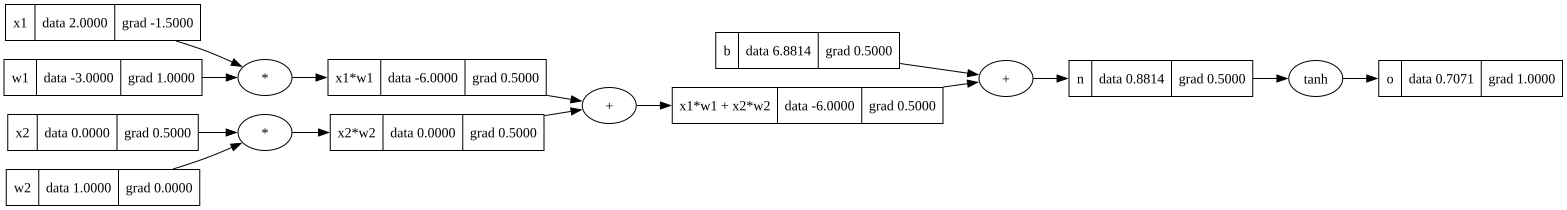

In [31]:
draw_dot(o)

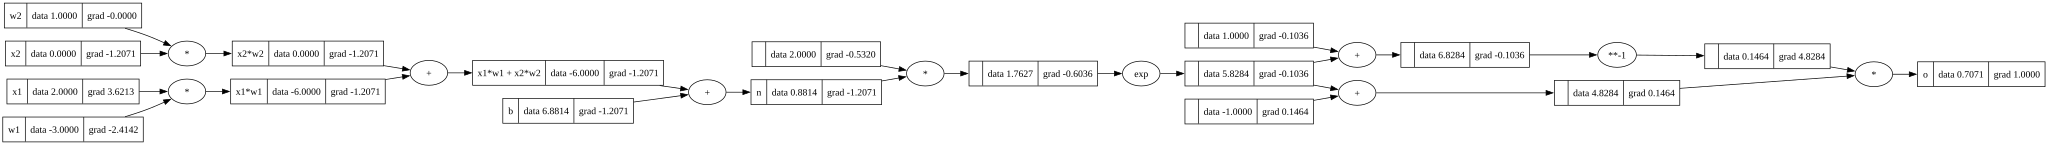

In [39]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#------------
#o = n.tanh();
#https://sl.bing.net/hwxluVwV9ky
#expcet long graph
#same backward pass 

e = (2*n).exp()
o = (e - 1) / (e + 1)
#-------------
o.label = 'o'
o.backward()
draw_dot(o)

In [46]:
#implement pytorch 

import torch

In [50]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(x)


tensor([[1, 2, 3],
        [4, 5, 6]])


In [51]:
torch.Tensor([2.0]).double().dtype

torch.float64

In [52]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [54]:
o.item()

0.7071066904050358

In [55]:
x2.grad.item()

0.5000001283844369

In [62]:
#building neuron

#Demonstration of using the neuron with example two-dimensional 
#input vectors is given. The explanation covers Python's call 
#method behavior and implementing the forward pass by multiplying 
#weight and input pairs (using zip) and summing the results, 
#preparing for the activation calculation.
import random

class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):

     #return 0.0
      print (list(zip(self.w,x)))
      return 0.0

x = [2.0,3.0]
n = Neuron(2)
n(x)

[(Value(data=-0.8248431785409864), 2.0), (Value(data=-0.6873191896642461), 3.0)]


0.0

In [65]:
import random

class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):

     #return 0.0
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

x = [2.0,3.0]
n = Neuron(2)
n(x)

Value(data=-0.013903407301154467)

In [72]:
#creating layer 
import random

class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):

     #return 0.0
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs

x = [2.0,3.0]
n = Layer(2,3)
n(x)

[Value(data=-0.9999774025738969),
 Value(data=-0.9302188844181543),
 Value(data=-0.9263954708722595)]

In [79]:
#creating MLP

#creating layer 
import random

class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):

     #return 0.0
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return  outs[0] if len(outs) == 1 else outs

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=0.15293300135031973)

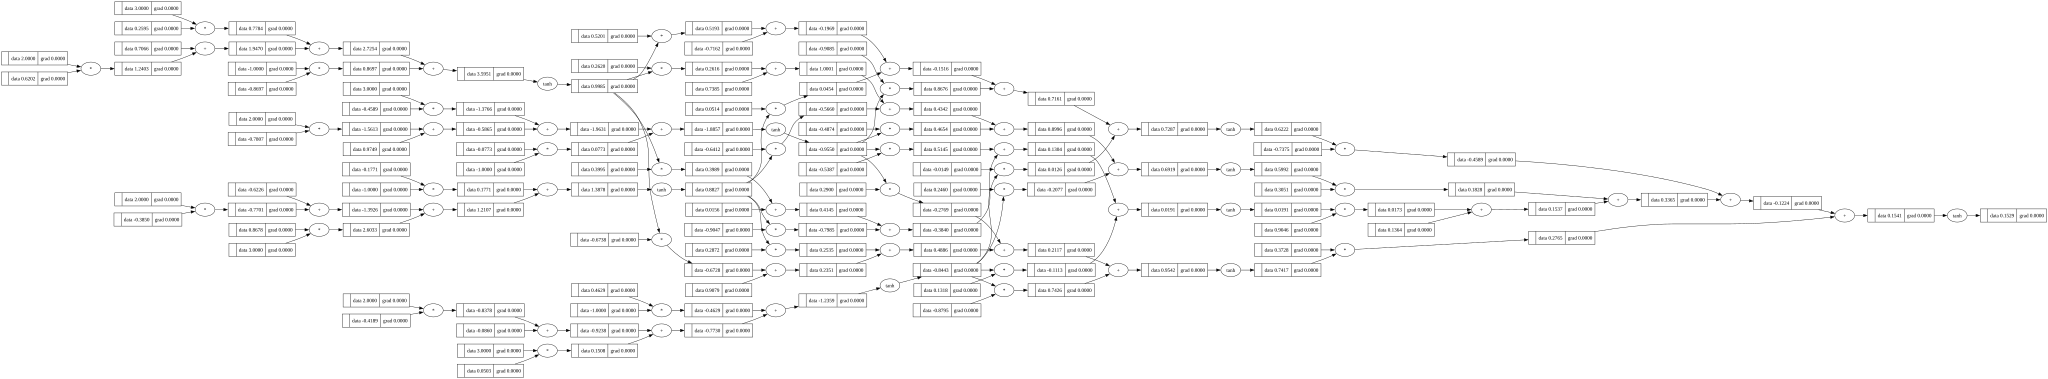

In [80]:
draw_dot(n(x))

In [88]:
#creating a tiny dataset, writing the loss function
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.15293300135031973),
 Value(data=0.8135277477433801),
 Value(data=0.8161717510568463),
 Value(data=0.7410316645704439)]

In [90]:
[(you -ygt) **2 for ygt , you in zip(ys,ypred)]

[Value(data=0.7175225002013774),
 Value(data=3.2888828918351773),
 Value(data=3.298479829336891),
 Value(data=0.06706459875515508)]

In [99]:
#loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred), start=Value(0.0))
loss = sum(((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)), start=Value(0.0))

print(loss)

Value(data=7.371949820128601)


In [100]:
loss.backward()

In [102]:
n.layers[0].neurons[0].w[0].grad

0.0009033268154257167

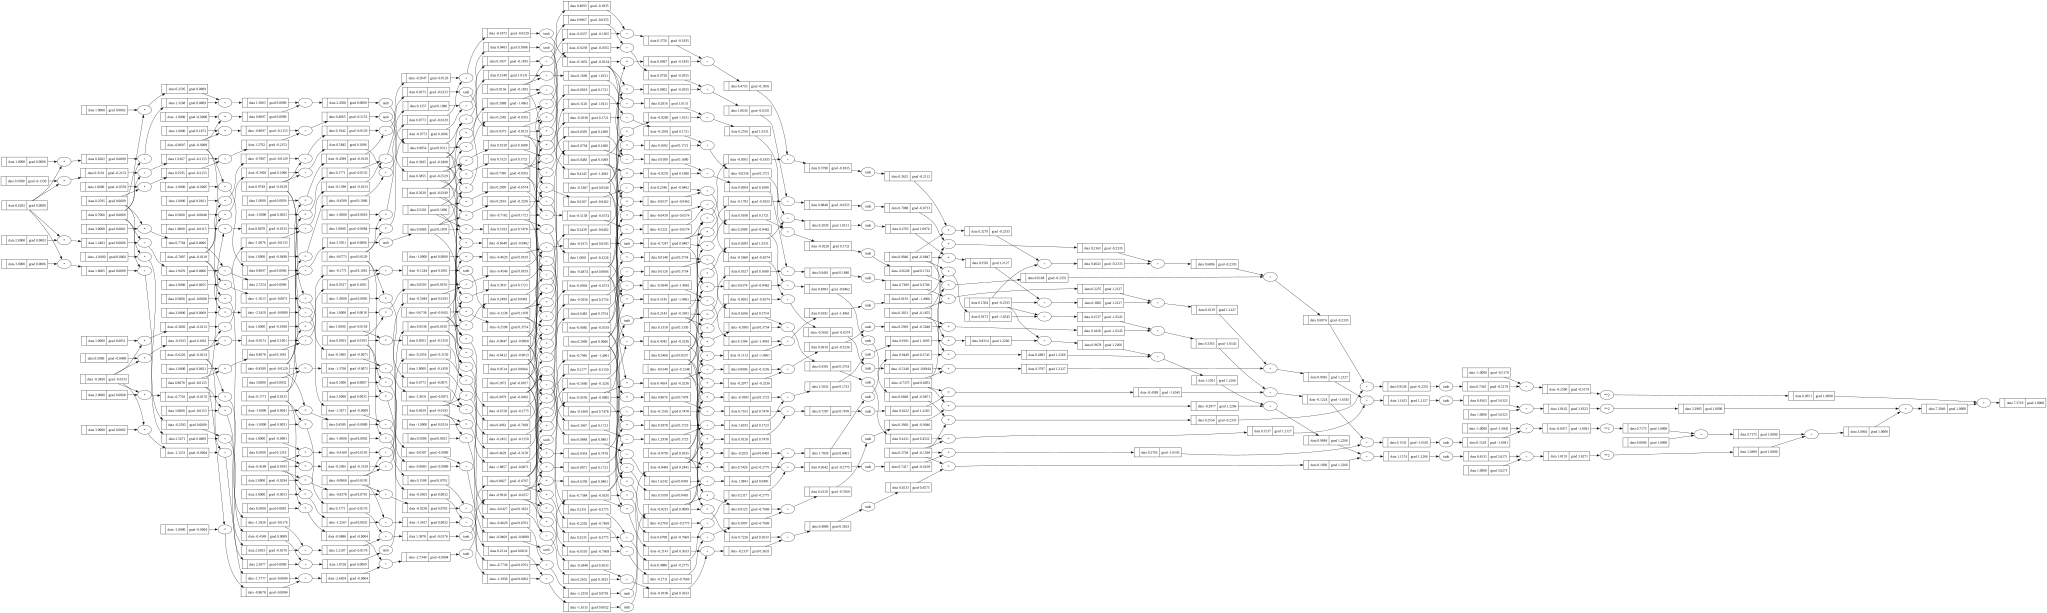

In [103]:
draw_dot(loss)

In [104]:
#collecting all of the parameter of the neural net 


import random

class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):

     #return 0.0
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return  outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
#params=[]
#for neuron in self.neurons
#params.extend(ps)
#return params

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]



In [105]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=-0.08764301862628182)

In [107]:
n.parameters()

[Value(data=0.03341773214755195),
 Value(data=-0.5797274433280883),
 Value(data=0.6578778102868958),
 Value(data=0.4458867278656593),
 Value(data=0.03236243172633557),
 Value(data=-0.13267220227630427),
 Value(data=0.2896626583810027),
 Value(data=0.25066520741105025),
 Value(data=0.18779979245877376),
 Value(data=0.5278349795530413),
 Value(data=0.5535531515172818),
 Value(data=-0.05533193158183525),
 Value(data=0.7826112596746932),
 Value(data=-0.596486428682758),
 Value(data=-0.9857471618139872),
 Value(data=0.2797993898742779),
 Value(data=0.08692251627445735),
 Value(data=0.2903531739804275),
 Value(data=0.8704639785480925),
 Value(data=-0.6954379665589983),
 Value(data=-0.34655908054255513),
 Value(data=0.3331989000078055),
 Value(data=-0.9698864504104392),
 Value(data=-0.34730516877586437),
 Value(data=0.31734458586125003),
 Value(data=-0.30219613171010273),
 Value(data=0.26994379076329444),
 Value(data=-0.37627662030809494),
 Value(data=-0.9146650725132863),
 Value(data=0.28390

In [108]:
len(n.parameters())

41

In [109]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.08764301862628182),
 Value(data=-0.5667478895491677),
 Value(data=-0.6913088235743108),
 Value(data=-0.4498076609461866)]

In [128]:
#loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred), start=Value(0.0))
loss = sum(((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)), start=Value(0.0))

print(loss)

Value(data=3.5679072233179188)


In [121]:
loss.backward()

In [122]:
n.layers[0].neurons[0].w[0].grad

1.521412921035234

In [123]:
n.layers[0].neurons[0].w[0].data

1.0286060480324841

In [130]:
#doing gradient descent optimization manually, training the network
for p in n.parameters():
  p.data += -0.01 + p.grad

In [131]:
n.layers[0].neurons[0].w[0].grad

1.521412921035234

In [159]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [166]:
ypred = [n(x) for x in xs]
loss = sum(((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)), start=Value(0.0))

print(loss)

Value(data=7.9999999999999885)


In [167]:
loss.backward()

In [168]:
for p in n.parameters():
  p.data += -0.01 + p.grad

In [169]:
n.layers[0].neurons[0].w[0].grad

-0.0

In [170]:
ypred

[Value(data=0.9999999999999997),
 Value(data=0.9999999999999989),
 Value(data=0.9999999999999982),
 Value(data=0.9999999999999996)]

In [172]:
n.parameters()

[Value(data=5.472844811138188),
 Value(data=4.8596996356625475),
 Value(data=-5.001549268703737),
 Value(data=5.885313806856296),
 Value(data=-0.46322772330077533),
 Value(data=-0.6282623573034154),
 Value(data=0.5652528134081138),
 Value(data=-0.2449249476160611),
 Value(data=-2.1638184660773065),
 Value(data=-1.8237832789830408),
 Value(data=2.6851714100533663),
 Value(data=-2.4069501901179158),
 Value(data=-1.577962135650844),
 Value(data=-2.9570598240082937),
 Value(data=1.1548262335115498),
 Value(data=-2.0807740054512576),
 Value(data=15.17038199357062),
 Value(data=3.465862530720708),
 Value(data=-1.7638718303055152),
 Value(data=-22.07433157614054),
 Value(data=-24.193557701439506),
 Value(data=-1.2541372805412583),
 Value(data=-1.3993529847766446),
 Value(data=-0.21185135176681563),
 Value(data=2.2754256635537358),
 Value(data=1.8958711608441314),
 Value(data=-31.833595623207504),
 Value(data=-7.404718944580264),
 Value(data=4.290940455993265),
 Value(data=44.960750821143044),

In [174]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [178]:
for k in range(20):
    
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)), start=Value(0.0))
    loss.backward()
    for p in n.parameters():
       p.data += -0.05 + p.grad
    
    print(k,loss.data)

0 7.9999999999999964
1 7.9999999999999964
2 7.9999999999999964
3 7.999999999999995
4 7.999999999999993
5 7.999999999999991
6 7.999999999999989
7 7.999999999999986
8 7.999999999999982
9 7.999999999999979
10 7.999999999999973
11 7.9999999999999645
12 7.999999999999956
13 7.999999999999943
14 7.999999999999925
15 7.9999999999999005
16 7.9999999999998685
17 7.999999999999828
18 7.999999999999773
19 7.999999999999698


In [177]:
ypred

[Value(data=0.9999999999999997),
 Value(data=0.9999999999999997),
 Value(data=0.9999999999999997),
 Value(data=0.9999999999999997)]

In [179]:
#zero grad bug 
for k in range(10):
    
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)), start=Value(0.0))
    for p in n.parameters():
        p.grad=0
    loss.backward()
    for p in n.parameters():
       p.data += -0.05 + p.grad
    
    print(k,loss.data)

0 7.999999999999598
1 7.999999999999463
2 7.999999999999282
3 7.99999999999904
4 7.999999999998713
5 7.999999999998274
6 7.999999999997681
7 7.999999999996882
8 7.999999999995802
9 7.9999999999943405


In [180]:
ypred

[Value(data=0.9999999999992945),
 Value(data=0.9999999999992945),
 Value(data=0.9999999999992909),
 Value(data=0.9999999999992945)]